In [3]:
!pip install python-dotenv

In [ ]:
import pandas as pd
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv
load_dotenv()

db_user = os.getenv("DB_USER")
db_pass = os.getenv("DB_PASS")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

db_url = f"postgresql://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}"
engine = create_engine(db_url)
query1="SELECT * FROM sales"
df_sales=pd.read_sql_query(query1,engine)
df_sales.head()




,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax,total,date,time,payment,cogs,gross_margin_percentage,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


Connection with the database and creation of the dataframe named df_sales which is the table sales from the pgadmin database. For the connection with the database I used enviromental variables.

In [64]:
df_sales.to_csv('supermarket_sales_RAW.csv', index=False)

Extract to a csv file the original df

In [5]:
df_sales['date'] = pd.to_datetime(df_sales['date'])
df_sales['time'] = pd.to_datetime(df_sales['time']).dt.time

C:\Users\mixal\AppData\Local\Temp\ipykernel_19800\1517091933.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sales['time'] = pd.to_datetime(df_sales['time']).dt.time


Now we start processing and cleaning the data. Because date and time were saved in db as strings now I convert them to the correct data types 

In [6]:
df_sales.info()
df_sales.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   invoice_id               1000 non-null   str           
 1   branch                   1000 non-null   str           
 2   city                     1000 non-null   str           
 3   customer_type            1000 non-null   str           
 4   gender                   1000 non-null   str           
 5   product_line             1000 non-null   str           
 6   unit_price               1000 non-null   float64       
 7   quantity                 1000 non-null   int64         
 8   tax                      1000 non-null   float64       
 9   total                    1000 non-null   float64       
 10  date                     1000 non-null   datetime64[us]
 11  time                     1000 non-null   object        
 12  payment                  1000 non-null   str  

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax,total,date,time,payment,cogs,gross_margin_percentage,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


In [7]:
df_sales=df_sales.drop_duplicates(subset=['invoice_id'])
df_sales=df_sales.drop_duplicates()
df_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   invoice_id               1000 non-null   str           
 1   branch                   1000 non-null   str           
 2   city                     1000 non-null   str           
 3   customer_type            1000 non-null   str           
 4   gender                   1000 non-null   str           
 5   product_line             1000 non-null   str           
 6   unit_price               1000 non-null   float64       
 7   quantity                 1000 non-null   int64         
 8   tax                      1000 non-null   float64       
 9   total                    1000 non-null   float64       
 10  date                     1000 non-null   datetime64[us]
 11  time                     1000 non-null   object        
 12  payment                  1000 non-null   str  

Now i delete the duplicate values in the dataframe. To be sure i delete any row which has the same invoice_id with other row. 

In [8]:


df_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   invoice_id               1000 non-null   str           
 1   branch                   1000 non-null   str           
 2   city                     1000 non-null   str           
 3   customer_type            1000 non-null   str           
 4   gender                   1000 non-null   str           
 5   product_line             1000 non-null   str           
 6   unit_price               1000 non-null   float64       
 7   quantity                 1000 non-null   int64         
 8   tax                      1000 non-null   float64       
 9   total                    1000 non-null   float64       
 10  date                     1000 non-null   datetime64[us]
 11  time                     1000 non-null   object        
 12  payment                  1000 non-null   str  

In [9]:
df_sales["unit_price"].min()

np.float64(10.08)

I check to see the min value of the unit_price because unit_price haw to always be greater than 0. Now min =10 so we have no problem

In [10]:
df_sales["cogs"].min()

np.float64(10.17)

Same as above I check to see the min value of the cogs because cogs haw to always be greater than 0. Now min =10 so we have no problem

In [11]:
df_sales["tax"].min()



np.float64(0.5085)

Same as above for tax

In [12]:
df_sales["total"].min()

np.float64(10.6785)

Same as above for total

In [13]:

df_sales["quantity"].min()

np.int64(1)

Same as above for quantity

In [14]:
df_sales["gross_income"].min()

np.float64(0.5085)

Same as above for gross_income

In [15]:
df_sales["rating"].min()

np.float64(4.0)

In [16]:
df_sales["rating"].max()

np.float64(10.0)

Now i chech to see if the rating is between 0 and 10

In [17]:
df_sales=df_sales.drop(columns=["gross_margin_percentage"])
df_sales.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax,total,date,time,payment,cogs,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,30.2085,5.3


Now i delete the column gross_margin_percentage because i noticed it is the same for every row 

In [18]:
df_ner=df_sales[["unit_price","quantity","tax","total"]]
df_ner.head()


,unit_price,quantity,tax,total
0,74.69,7,26.1415,548.9715
1,15.28,5,3.8200,80.2200
2,46.33,7,16.2155,340.5255
3,58.22,8,23.2880,489.0480
4,86.31,7,30.2085,634.3785


Now i noticed that the way total is computed is by the type: total=unit_price*quantity + tax. So I have to check if all the rows have the correct-right total. So i make a new df with these columns

In [19]:
import numpy as np
df_ner["our_total"]=np.nan
df_ner.head()

,unit_price,quantity,tax,total,our_total
0,74.69,7,26.1415,548.9715,NaN
1,15.28,5,3.8200,80.2200,NaN
2,46.33,7,16.2155,340.5255,NaN
3,58.22,8,23.2880,489.0480,NaN
4,86.31,7,30.2085,634.3785,NaN


I put one extra column to the new df in which I am going to put the right prices for the total as computed with the type i mentioned and then i am going to compare the prices from this new col with the prices of the total col

In [20]:
df_ner["our_total"]=df_ner["unit_price"]*df_ner["quantity"]+df_ner["tax"]
df_ner.head()


,unit_price,quantity,tax,total,our_total
0,74.69,7,26.1415,548.9715,548.9715
1,15.28,5,3.8200,80.2200,80.2200
2,46.33,7,16.2155,340.5255,340.5255
3,58.22,8,23.2880,489.0480,489.0480
4,86.31,7,30.2085,634.3785,634.3785


I fill in the column our_total

In [21]:
df_ner["compare"]=np.nan
df_ner.head()

,unit_price,quantity,tax,total,our_total,compare
0,74.69,7,26.1415,548.9715,548.9715,NaN
1,15.28,5,3.8200,80.2200,80.2200,NaN
2,46.33,7,16.2155,340.5255,340.5255,NaN
3,58.22,8,23.2880,489.0480,489.0480,NaN
4,86.31,7,30.2085,634.3785,634.3785,NaN


Now i put one extra column named compare which is going to store the difference between the 2 col

In [22]:
df_ner["compare"]=df_ner["total"]-df_ner["our_total"]
df_ner['compare'] = df_ner['compare'].round(2)
df_ner.head()


,unit_price,quantity,tax,total,our_total,compare
0,74.69,7,26.1415,548.9715,548.9715,0.0
1,15.28,5,3.8200,80.2200,80.2200,0.0
2,46.33,7,16.2155,340.5255,340.5255,0.0
3,58.22,8,23.2880,489.0480,489.0480,0.0
4,86.31,7,30.2085,634.3785,634.3785,0.0


I use round(2) after the subtraction between the 2 columns to avoid tiny differences caused by floating-point precision errors.
Even when two values should be equal, direct subtraction may return very small non-zero numbers.
Rounding to two decimals matches the currency precision and helps verify that the difference is effectively zero.

In [23]:
df_ner["compare"].min()

np.float64(0.0)

In [24]:
df_ner["compare"].max()

np.float64(0.0)

Now i check to see the min and max of the compare col, because both are 0 that means that the prices in the total col ar correct

In [25]:
df_kat=df_sales[['cogs','gross_income','total']]
df_kat.head()

,cogs,gross_income,total
0,522.83,26.1415,548.9715
1,76.40,3.8200,80.2200
2,324.31,16.2155,340.5255
3,465.76,23.2880,489.0480
4,604.17,30.2085,634.3785


Now as above i noticed that the other way total is computed is by the type: total=cogs+gross_income. So i make a new df 

In [26]:
df_kat["our_total"]=df_kat["cogs"]+df_kat["gross_income"]
df_kat.head()

,cogs,gross_income,total,our_total
0,522.83,26.1415,548.9715,548.9715
1,76.40,3.8200,80.2200,80.2200
2,324.31,16.2155,340.5255,340.5255
3,465.76,23.2880,489.0480,489.0480
4,604.17,30.2085,634.3785,634.3785


I put one extra column to the new df in which I am going to put the right prices for the total as computed with the type i mentioned and then i am going to compare the prices from this new col with the prices of the total col

In [27]:
df_kat["compare"]=df_kat["total"]-df_kat["our_total"]
df_kat['compare']=df_kat['compare'].round(3)
df_kat.head()


,cogs,gross_income,total,our_total,compare
0,522.83,26.1415,548.9715,548.9715,0.0
1,76.40,3.8200,80.2200,80.2200,0.0
2,324.31,16.2155,340.5255,340.5255,0.0
3,465.76,23.2880,489.0480,489.0480,0.0
4,604.17,30.2085,634.3785,634.3785,0.0


I use round(2) after the subtraction between the 2 columns to avoid tiny differences caused by floating-point precision errors.
Even when two values should be equal, direct subtraction may return very small non-zero numbers.
Rounding to two decimals matches the currency precision and helps verify that the difference is effectively zero.

In [28]:
df_kat["compare"].min()

np.float64(0.0)

In [29]:
df_kat["compare"].max()

np.float64(0.0)

Now i see that max and min of the compare col are 0 so the total prices are correct

In [30]:
df_sales['month']=pd.to_datetime(df_sales["date"]).dt.month
df_sales.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax,total,date,time,payment,cogs,gross_income,rating,month
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,26.1415,9.1,1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,3.8200,9.6,3
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,16.2155,7.4,3
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,23.2880,8.4,1
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,30.2085,5.3,2


To be able to extract more easily info about the months of the sales i decides to make another column in my df called month in which the number of the month is stored

In [31]:
df_sales['day']=pd.to_datetime(df_sales["date"]).dt.day
df_sales.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax,total,date,time,payment,cogs,gross_income,rating,month,day
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,26.1415,9.1,1,5
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,3.8200,9.6,3,8
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,16.2155,7.4,3,3
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,23.2880,8.4,1,27
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,30.2085,5.3,2,8


To be able to extract more easily info about the days of the sales i decided to make another column in my df called day in which the number of the day is stored

In [32]:
df_sales['month_name']=df_sales['date'].dt.month_name()
df_sales.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax,total,date,time,payment,cogs,gross_income,rating,month,day,month_name
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,26.1415,9.1,1,5,January
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,3.8200,9.6,3,8,March
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,16.2155,7.4,3,3,March
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,23.2880,8.4,1,27,January
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,30.2085,5.3,2,8,February


To make it even easier for me i made another col named month_name which contains the name of the month in which the transaction occured

In [33]:
df_sales['day_name']=df_sales['date'].dt.day_name()
df_sales.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax,total,date,time,payment,cogs,gross_income,rating,month,day,month_name,day_name
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,26.1415,9.1,1,5,January,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,3.8200,9.6,3,8,March,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,16.2155,7.4,3,3,March,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,23.2880,8.4,1,27,January,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,30.2085,5.3,2,8,February,Friday


To make it even easier for me i made another col named day_name which contains the name of the day in which the transaction occured

In [34]:
bins=[0,200,500,100000]
lab=["Low","Medium","High"]

df_sales["total_cat"]=pd.cut(df_sales["total"],bins=bins, labels=lab, include_lowest=True)
df_sales.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax,total,...,time,payment,cogs,gross_income,rating,month,day,month_name,day_name,total_cat
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,13:08:00,Ewallet,522.83,26.1415,9.1,1,5,January,Saturday,High
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,10:29:00,Cash,76.40,3.8200,9.6,3,8,March,Friday,Low
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,...,13:23:00,Credit card,324.31,16.2155,7.4,3,3,March,Sunday,Medium
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,...,20:33:00,Ewallet,465.76,23.2880,8.4,1,27,January,Sunday,Medium
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,...,10:37:00,Ewallet,604.17,30.2085,5.3,2,8,February,Friday,High


Now i make a categorization foe the total expenses in every transaction. So if the total expense are lower than 200 then they are considered low, if the are between 200 and 500 they are considered medium and if they are greater than 500 they are considered high

In [35]:
df_sales['total'].sum()

np.float64(322966.749)

Now i find the sum of the total col

In [36]:
df_sales['rating'].mean()

np.float64(6.9727)

Now i find the avg rating of all the supermarket branches

In [37]:
group=df_sales.groupby("gender")
print(group["total"].mean())

gender
Female    335.095659
Male      310.789226
Name: total, dtype: float64


Now i want to know if by average the men or the women spent more on total expenses by each transaction. I find out that by average women spend more 25 more dollars compared to men.

In [52]:
groupm=df_sales.groupby(["gender","customer_type"])
print(groupm["total"].mean())


gender  customer_type
Female  Member           337.727753
        Normal           332.233256
Male    Member           316.985419
        Normal           305.047581
Name: total, dtype: float64


Now to have more info about the money spend by gender I found out that the women members pay about 20,74 more dollars than men members while female non member-normal customers pay 27,19 more dollars than non members men 

In [54]:
groupf=df_sales.groupby("gender")
print(groupf["quantity"].mean())

gender
Female    5.726547
Male      5.292585
Name: quantity, dtype: float64


Now we notice something interesting, although women pay 25 more dollars more than men by average the average quantity of products the genders buy is pretty close(5.7265 for women and 5.292 for men). 

In [57]:
groupf1=df_sales.groupby(["gender","product_line"])
print(groupf1["total"].mean())

gender  product_line          
Female  Electronic accessories    322.643125
        Fashion accessories       317.056250
        Food and beverages        368.565750
        Health and beauty         290.015414
        Home and lifestyle        380.213639
        Sports and travel         324.712739
Male    Electronic accessories    316.691965
        Fashion accessories       291.079207
        Food and beverages        273.499125
        Health and beauty         348.099460
        Home and lifestyle        294.136241
        Sports and travel         340.360327
Name: total, dtype: float64


So now i notice that women pay the most money by average in home and lifestyle products and the less in health and beauty. The men by a suprise they pay the most money by average in the health and beauty products and the less money in the fashion accessories

<Axes: xlabel='total', ylabel='product_line'>

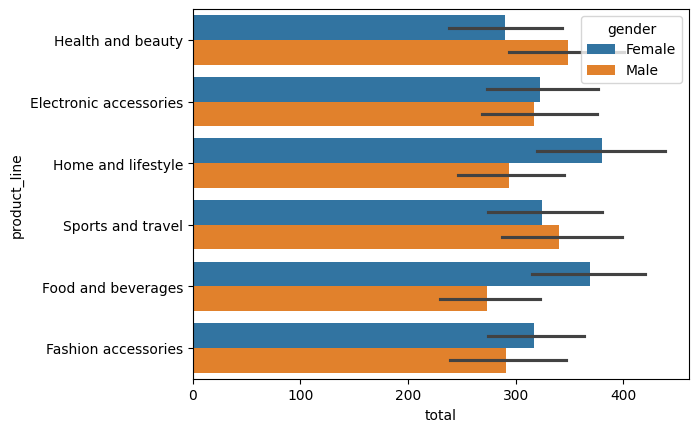

In [62]:
sns.barplot(x='total',y="product_line",data=df_sales, hue="gender")

I wanted to visualize the data found previously.

In [38]:
group1=df_sales.groupby("payment")
print(group1["invoice_id"].count())

payment
Cash           344
Credit card    311
Ewallet        345
Name: invoice_id, dtype: int64


Now i want to know which method of payment is the most popular

In [39]:
group2=df_sales.groupby("branch")
print(group2["invoice_id"].count())

branch
A    340
B    332
C    328
Name: invoice_id, dtype: int64


Now i want to see which branch had the most total transactions 

In [40]:
group3=df_sales.groupby('day_name')
print(group3["invoice_id"].count())

day_name
Friday       139
Monday       125
Saturday     164
Sunday       133
Thursday     138
Tuesday      158
Wednesday    143
Name: invoice_id, dtype: int64


Now we want to see in which day the most transactions-payments occur. That happens on Saturdays as proven while Mondays are the most "slow" days

In [41]:
group4=df_sales.groupby('month_name')
print(group4["invoice_id"].count())

month_name
February    303
January     352
March       345
Name: invoice_id, dtype: int64


We now want to find out the total transactions by each month, we see that January was the busiest month

In [42]:
groub5=df_sales.groupby("product_line")
print(groub5["total"].sum().sort_values())

product_line
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Fashion accessories       54305.8950
Electronic accessories    54337.5315
Sports and travel         55122.8265
Food and beverages        56144.8440
Name: total, dtype: float64


Now I want to find out which product_line of the products brings in the most cash in the supermarkets and that is the food and beverages

In [43]:
groub6=df_sales.groupby("customer_type")
print(groub6["total"].mean())

customer_type
Member    327.791305
Normal    318.122856
Name: total, dtype: float64


Now i want to check if the customers that are members of the supermarkets spend by avg more money than the regural customer. It is proven that by avg the members spend about 9 dollars more than non members

In [44]:
group7=df_sales.groupby(['branch','gender'])
print(group7["invoice_id"].count())

branch  gender
A       Female    161
        Male      179
B       Female    162
        Male      170
C       Female    178
        Male      150
Name: invoice_id, dtype: int64


Now for last i want to see the gender of the customers on total in each supermarket branch

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='total', ylabel='product_line'>

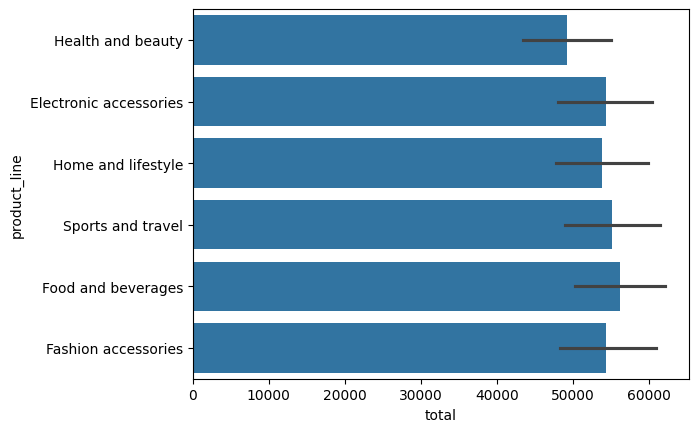

In [59]:
sns.barplot(x='total',y="product_line",data=df_sales,estimator=sum)

I made a bar-chart to observe which product line brings in the most money on the supermarket

([<matplotlib.patches.Wedge at 0x191d13d0830>,
 [Text(-0.9721422587331681, 0.5147226717225253, 'Ewallet'),
  Text(0.11727253893915701, -1.0937308405685395, 'Cash'),
  Text(0.9117261857771254, 0.615431037703084, 'Credit card')],
 [Text(-0.5302594138544552, 0.2807578209395592, '34.5%'),
  Text(0.06396683942135836, -0.5965804584919305, '34.4%'),
  Text(0.4973051922420683, 0.33568965692895486, '31.1%')])

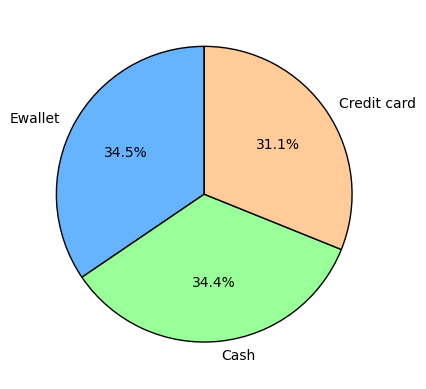

In [47]:
payment_counts=df_sales["payment"].value_counts()
plt.pie(payment_counts,labels=payment_counts.index,autopct='%1.1f%%',                 
        colors=['#66b3ff', '#99ff99', '#ffcc99'], 
        startangle=90,                     
        wedgeprops={'edgecolor': 'black'})



Now I made a pie chart about to observe which kind of payment the customers prefer the most. We see that ewallet is the most commonly used

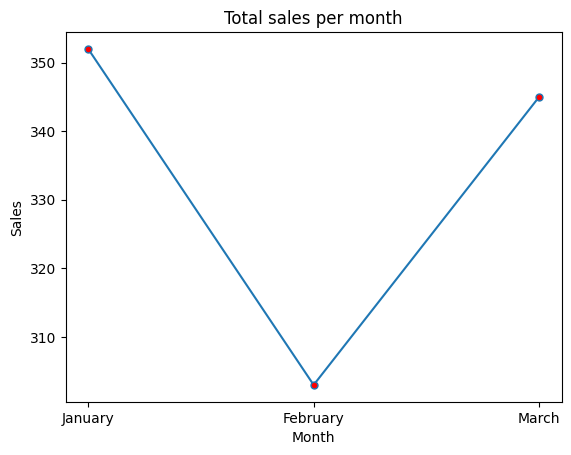

In [48]:
y=df_sales["month_name"].value_counts()
x1=["January","February","March"]
y1=[352,303,345]

plt.plot(x1,y1,marker=".",markersize=10,markerfacecolor="red")
plt.title("Total sales per month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Now we wanted to see how the total sales were affected by the month, I notice that in January the supermarkets had the most sales while the February had the least amount

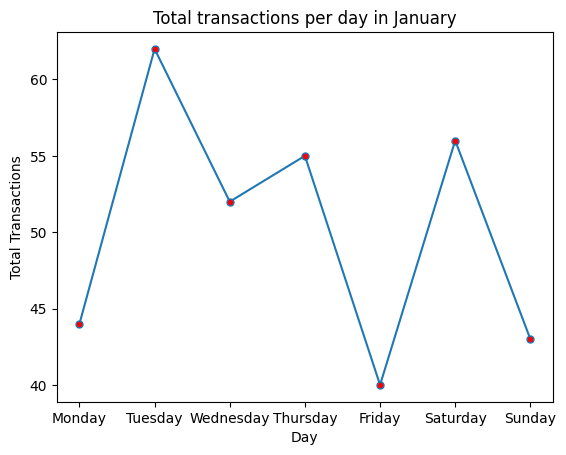

In [49]:
mike=df_sales[df_sales["month_name"]=="January"]
mike.head()
mike["day_name"].value_counts()
xm=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
ym=[44,62,52,55,40,56,43]
plt.plot(xm,ym,marker=".",markersize=10,markerfacecolor="red")
plt.title("Total transactions per day in January")
plt.xlabel("Day")
plt.ylabel("Total Transactions")
plt.show()

Now I wnated to know which days had the most transactions in the busiest month, We notice that Tuesday was the busiest day of this month

<Axes: >

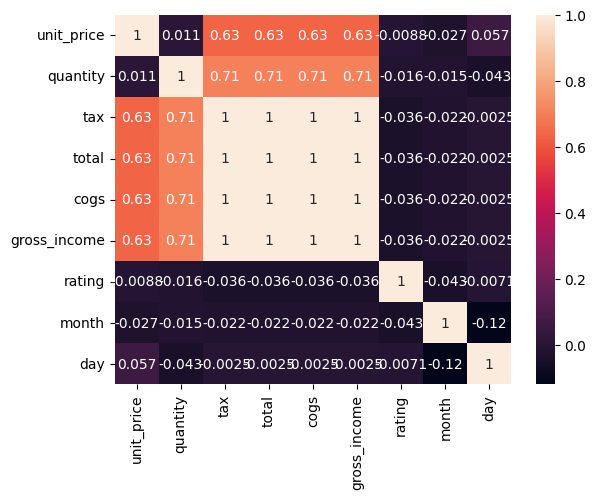

In [50]:
sns.heatmap(df_sales.corr(numeric_only=True),annot=True)

I made a heatmap for the df_sales. We observe that the columns tax, total, cogs, and gross_income have a perfect correlation of 1 with each other. Why? Because, as we proved earlier, one is mathematically derived from the other! When the cost (cogs) goes up, the profit, tax, and total amount inevitably increase as well. We also notice that rating and total have a correlation close to 0, which means that if a customer pays a lot of money at the checkout, it doesn't mean they will also give a good rating

In [63]:
# Εξαγωγή του DataFrame σε αρχείο CSV
df_sales.to_csv('supermarket_sales_CLEANED.csv', index=False)

I made a csv file from the final df 

Finally I have some final conclusions-business insights from my analysis:

1. I noticed that customers who are members (Member) spend more money on average per receipt (327.79) than regular customers (318.12). That means that the membership program is effective. The business should invest in marketing campaigns (e.g., sign-up offers at the checkout) to convert 'Normal' customers into 'Members', thereby increasing its total revenue.

2. From the Heatmap I created, I observed that the rating and total have a correlation close to 0. This means that just because a customer spends a lot of money, it does not mean they will also give a good rating. Furthermore, the average rating is only 6.97. So the Management should not become complacent when seeing high revenues. Customers are spending money, but they are not leaving excited as we see from the average rating. The reasons behind the mediocre ratings must be investigated (perhaps through questionnaires) in order to improve the in-store experience for the customers.

3. I found that the 'Food and beverages' category generates the most revenue (56144.84), while 'Health and beauty' generates the least (49193.73). Also, January is the busiest month (352 receipts) with February showing a significant drop (303), while Saturday is the day with the most purchases. The supermarket can reduce its operating expenses by adjusting staff shifts (more personnel on Saturdays and in January, fewer in February). At the same time, 'Food and beverages' products should be placed in more strategic locations within the store, as they are the flagship revenue driver.

4. I noticed that men pay about 25 less dollars by average compared to women. Also I found out that the women members pay about 20,74 more dollars than men members while female non member-normal customers pay 27,19 more dollars than non members men. So since women are by far the supermarket's most profitable customer segment, advertising campaigns and promotional activities (e.g., premium products, offers on high-end items) should primarily target them. Also the business 'loses' approximately $25 every time a male customer reaches the checkout. It should be investigated which product categories men prefer (e.g., Electronic accessories), and special bundles or strategic shelf placements near the cash registers should be created, so that they men are goiing to add 1-2 extra products to their basket

5. Although women spend an average of about $25 more than men at the checkout, the number of items they purchase is nearly identical (5.7 items for women versus 5.3 for men). The difference in revenue does not come from women 'filling their baskets more,' but rather from them choosing more expensive products (or products with higher profit margins). Therefore, the store's strategy towards female customers shouldn't be 'buy more items,' but rather 'buy our premium/expensive products.

6. Men spend by far the most of their money in the 'Health and beauty' category (averaging ~$348), showing a huge difference compared to women (~$290) in this specific category! They also have a strong presence in 'Sports and travel'. In contrast, women drive the store's revenue in 'Home and lifestyle' (~$380) and 'Food and beverages' (~$368). The supermarket needs to stop generic promotional campaigns and transition to Targeted Marketing.

7. Health and Beauty products, as well as Sports items, should be placed in high-visibility areas for male customers, perhaps even near the checkouts (for impulse buys), since it has been proven that they are willing to spend large amounts on them. Similarly, Home & lifestyle and Food items must be at the center of promotions when the store targets a female audience (e.g., in targeted emails or SMS if they hold a membership card).